## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Answers:
1. If the target variable y is categorical, then we do k-NN classification. If the target variable is numeric, then we do k-NN regression.
2. A confusion matrix helps us evaluate fit and see if we're making good or bad predictions. Confusion matrices are used for classification tasks, where true labels are cross-tabulated with predicted ones. In regards to a model's performance, it answers the question: "did it work?"
3. Accuracy describes the simplified, single summary number of a confusion matrix. It reveals what proportion of cases was predicted accurately. Accuracy is calculated by adding the number of cases on the diagonal portion of the confusion matrix and dividing it by the total amount of observations. It might not be sufficient to evaluate predictive performance because it doesn't consider other factors such as a dataset with skewed or imbalanced data.
4. Root mean squared error quantifies the distance from the true values to the predicted values for regression models. Since this value is weighted by sample size, the value approaches a fixed value as n gets larger.
5. Overfitting occurs when the k is too low. A model is sensitive to low numbers of data points. Underfitting occurs when the k is too high. The model will average many observations and provide answers close to population proportions.
6. Splitting the data into training and testing sets improves model performance as it allows us to replicate the experience of making predictions with the model for new cases that the model is unfamiliar with. This uncertainty is replicated with train-test splits where the model is trained by training data, and performance metrics are computed by test data. The model's performance on the test data signals its future performance. Additionally, choosing k by evaluating accuracy or RMSE helps us to measure how k performs on unseen data.
7. Reporting a class label as a prediction is simpler than a probability distribution over class labels. However, given that it's a prediction, reporting a class label is not as solid or insightful as a probability distribution. Probability distributions might be harder to interpret, but they may be safer than reporting a class label.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [64]:
#1
import numpy as np
import pandas as pd

df = pd.read_csv('./data/land_mines.csv', encoding='latin1')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [65]:
#1
df.value_counts(dropna=False)
# Checking the unique values and their counts.

voltage   height    soil  mine_type
0.197734  0.818182  0.8   4            1
0.422960  0.181818  0.2   5            1
0.439214  1.000000  0.0   2            1
0.438066  0.545455  0.2   2            1
          0.454545  0.2   4            1
                                      ..
0.323262  0.909091  0.8   5            1
                    0.4   5            1
          0.818182  0.8   1            1
          0.545455  1.0   5            1
0.999999  0.545455  0.4   2            1
Name: count, Length: 338, dtype: int64

In [66]:
#1
df.isna().sum()
# Checking that none of the features contain NaN values.

voltage      0
height       0
soil         0
mine_type    0
dtype: int64

In [67]:
#1
df.describe()
# Checking statistics of each feature.
# Confused how soil can be 0 and what that means.

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


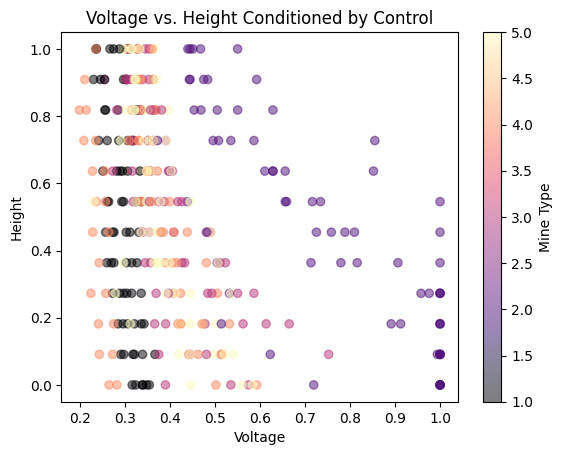

In [68]:
#1
import matplotlib.pyplot as plt

control_map = {
    1: 1, 
    2: 2, 
    3: 3,
    4: 4,
    5: 5
}

colors = df['mine_type'].map(control_map)

plt.scatter(df['voltage'], df['height'], c=colors, cmap='magma', alpha=0.5)
plt.colorbar(label='Mine Type')

plt.xlabel("Voltage")
plt.ylabel("Height")
plt.title("Voltage vs. Height Conditioned by Control")
plt.show()

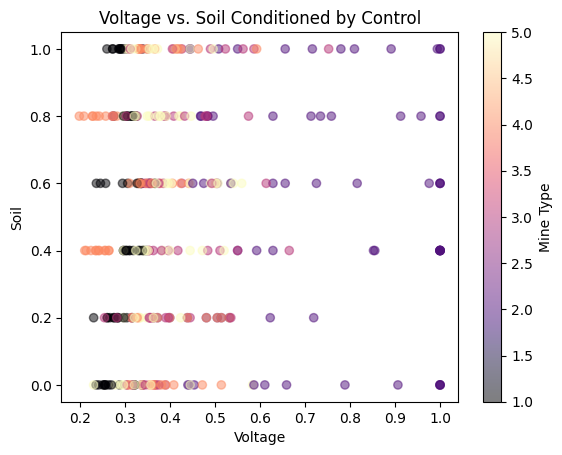

In [69]:
#1
import matplotlib.pyplot as plt

control_map = {
    1: 1, 
    2: 2, 
    3: 3,
    4: 4,
    5: 5
}

colors = df['mine_type'].map(control_map)

plt.scatter(df['voltage'], df['soil'], c=colors, cmap='magma', alpha=0.5)
plt.colorbar(label='Mine Type')

plt.xlabel("Voltage")
plt.ylabel("Soil")
plt.title("Voltage vs. Soil Conditioned by Control")
plt.show()

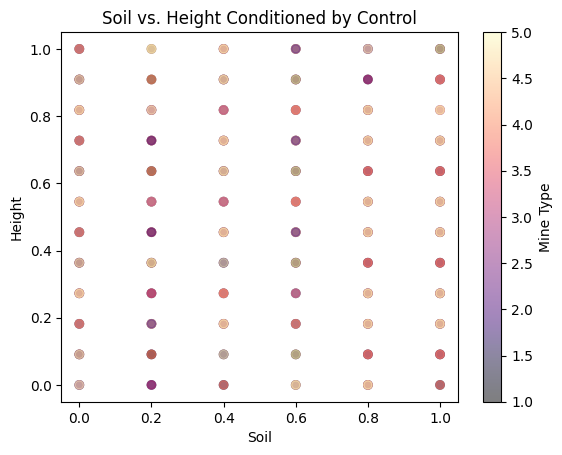

In [70]:
#1
import matplotlib.pyplot as plt

control_map = {
    1: 1, 
    2: 2, 
    3: 3,
    4: 4,
    5: 5
}

colors = df['mine_type'].map(control_map)

plt.scatter(df['soil'], df['height'], c=colors, cmap='magma', alpha=0.5)
plt.colorbar(label='Mine Type')

plt.xlabel("Soil")
plt.ylabel("Height")
plt.title("Soil vs. Height Conditioned by Control")
plt.show()

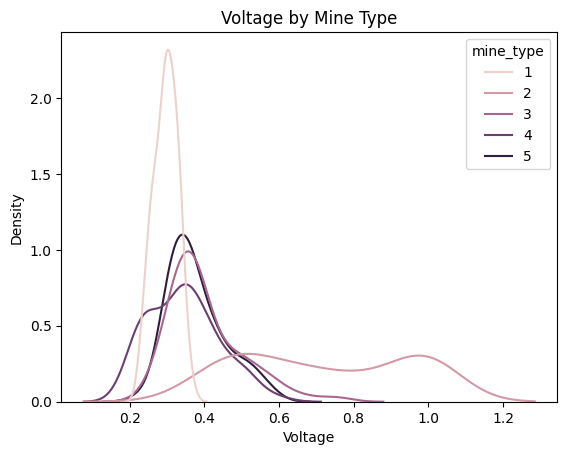

,count,mean,std,min,25%,50%,75%,max
mine_type,,,,,,,,
1,71.0,0.296463,0.031672,0.229607,0.273096,0.296586,0.320241,0.365861
2,70.0,0.721123,0.222267,0.362537,0.505286,0.714501,0.998488,0.999999
3,66.0,0.402408,0.098185,0.253776,0.339879,0.371601,0.441087,0.752265
4,66.0,0.345365,0.092564,0.197734,0.263074,0.336858,0.407099,0.592144
5,65.0,0.379598,0.076340,0.229607,0.323262,0.362537,0.422840,0.583081


In [71]:
#1
# I was a little confused by the scatterplots I created as I couldn't observe any obvious correlations.
# I think my only guess is that mine type could be based on voltage since those points were th least random from what I saw.
# Using a KDE plot to check out the trend for voltage.

import seaborn as sns
sns.kdeplot(df, x = 'voltage', hue = 'mine_type')

plt.xlabel("Voltage")
plt.title("Voltage by Mine Type")
plt.show()

df.groupby('mine_type')['voltage'].describe()

# Based on this KDE plot, my observations about mine type were confirmed.
# I saw that mine type 2 had the most widely distributed points on the scatterplots.
# Mine type 2 had the widest distribution on the KDE plot. 

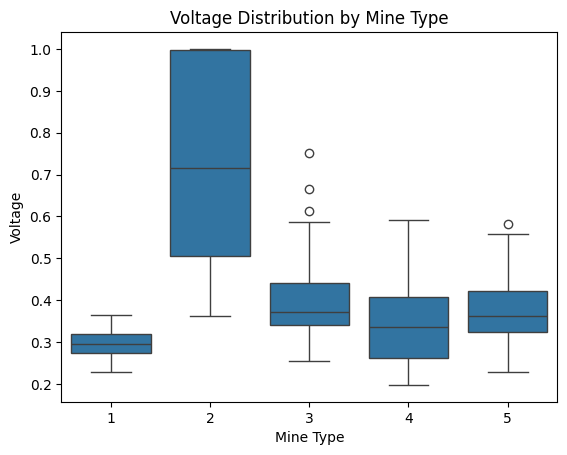

In [72]:
#1
# Hopefully this box plot can confirm if voltage could be the mine type definer.

sns.boxplot(df, x = 'mine_type', y = 'voltage')
plt.xlabel("Mine Type")
plt.ylabel("Voltage")
plt.title("Voltage Distribution by Mine Type")
plt.show()

Question 1: My ultimate conclusion from performing EDA on the landmine dataset is that voltage is indicative for mine type. I concluded this primarily from the scatterplots, KDE plot, and boxplot I created. In comparison, I think soil and height are more randomly distributed.

In [71]:
pip install scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [73]:
#2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

u = df[['voltage', 'soil', 'height']] 
y = df['mine_type']

scaler = MinMaxScaler()
u_scaled = scaler.fit_transform(u)

u_train, u_test, y_train, y_test = train_test_split(u,y, 
                                                    test_size=.5, 
                                                    random_state=100) 
df = df.sample(frac=1, random_state = 100)
test_size = int( .5 * len(df) ) 
df_test = df.iloc[:test_size,:].reset_index(drop=True)
df_train = df.iloc[test_size:,:].reset_index(drop=True)

print(len(u_train)) 
print(len(u_test))

169
169


Text(0.5, 1.0, 'k-NN Classifier Model for Landmines')

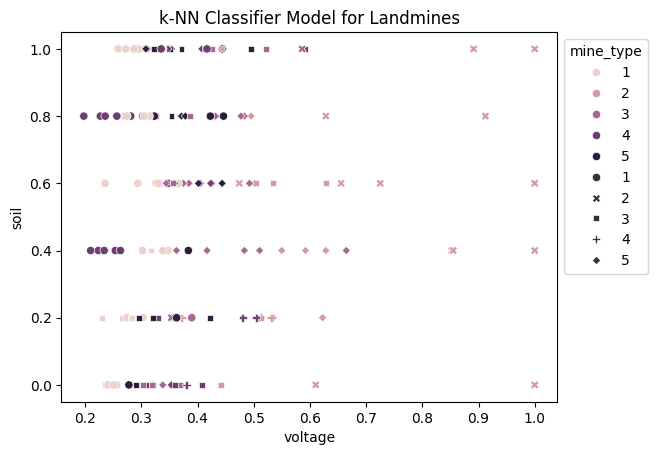

In [74]:
#3
from sklearn.neighbors import KNeighborsClassifier

k = 13 
model = KNeighborsClassifier(n_neighbors = k)
model.fit(u_train,y_train)
y_hat = model.predict(u_test)

landmine_plot = sns.scatterplot(x = u_test['voltage'],y = u_test['soil'],
                hue = y_test,
                style=y_hat)
sns.move_legend(landmine_plot, "upper left", bbox_to_anchor=(1, 1))
plt.title("k-NN Classifier Model for Landmines")

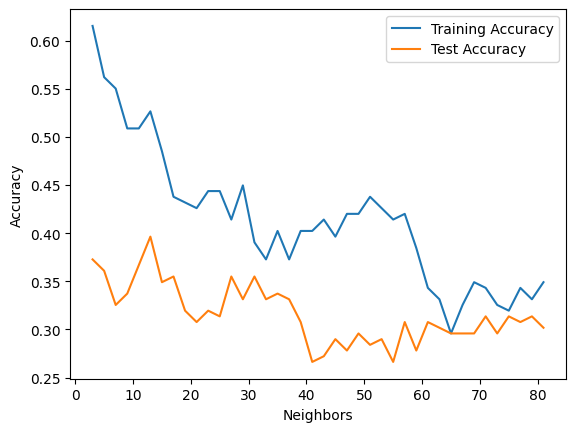

[13]


In [75]:
#3: finding the optimal k value to use

k_grid = np.array([ (2*k+3) for k in range(0,40)])

test_accuracies = []
train_accuracies = []

for k in k_grid: 
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(u_train,y_train)
    test_accuracies.append(model.score(u_test, y_test))
    train_accuracies.append(model.score(u_train, y_train))
    
sns.lineplot(x=k_grid,y=train_accuracies,label='Training Accuracy').set(xlabel='Neighbors',ylabel='Accuracy')
sns.lineplot(x=k_grid,y=test_accuracies,label='Test Accuracy')
plt.show()

is_optimal = test_accuracies == np.max(test_accuracies)
optimal_indices = np.where( is_optimal )
k_optimal = k_grid[ optimal_indices ]

print(k_optimal)

Question 3: I selected my k value by choosing k and finding the "optimal" k. I found that the optimal k value was 13.

In [76]:
#4
pd.crosstab(y_test,y_hat)

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[26,  0, 10,  0,  2],
       [ 0, 21,  7,  2,  5],
       [ 3,  3,  8,  0, 19],
       [17,  0,  7,  4,  7],
       [ 7,  0, 13,  0,  8]])

In [77]:
test_acc = model.score(u_test, y_test)
print(test_acc)

0.30177514792899407


Question 4: Based on the confusion matrix, I can see that mine type 1 had 26 correct predictions, mine type 2 had 21 correct predictions, mine type 3 had 8 correct predictions, mine type 4 had 4 correct predictions, and mine type 5 had 8 correct predictions. This was concluded based on the numbers running diagonally. We can see that the model was decently accurate when predicting mine types 1 and 2 but very poor at predicting mine type 4.

Question 5: I would advise someone to use this model for classifying mines as type 1 or even type 2. I would advise against using the model for predicting other types since it performed poorly. This may be because of confusing voltage distributions that aren't as distinct for these types. Overall, the model prediction accuracy wasn't great either as it was only about 30% accurate.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [78]:
#1
import numpy as np
import pandas as pd

df_3 = pd.read_csv('./data/USA_cars_datasets.csv', encoding='latin1')
df_3.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [79]:
#1
df3_subset = df_3.loc[:, ['price', 'year', 'mileage']]
df_3=df3_subset
df_3.head()


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [80]:
#1
print(df_3.isnull().sum())

price      0
year       0
mileage    0
dtype: int64


Question 1: There aren't any NA's to handle.

In [81]:
#2
from sklearn.preprocessing import MinMaxScaler

y_3 = df_3['price']
ctrl_list3 = ['year', 'mileage']
x_3 = df_3.loc[:, ctrl_list3]
scaler = MinMaxScaler()
u_3 = scaler.fit_transform(x_3)

In [82]:
#3
u_train3, u_test3, y_train3, y_test3 = train_test_split(u_3,y_3, 
                                                    test_size=.2, 
                                                    random_state=100) 

print(len(u_train3))
print(len(u_test3))

1999
500


k=3, MSE: 126118037.16


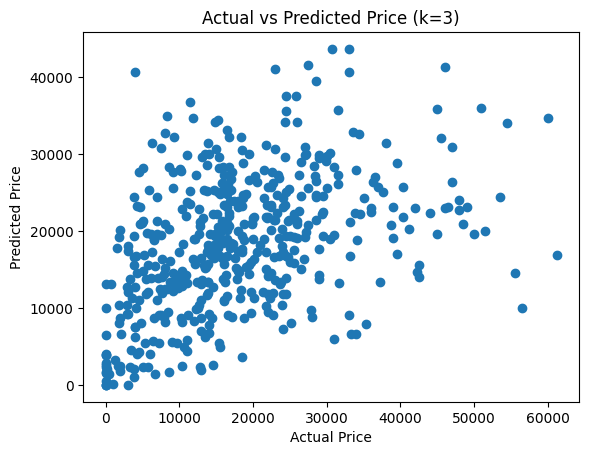

k=10, MSE: 110653044.19


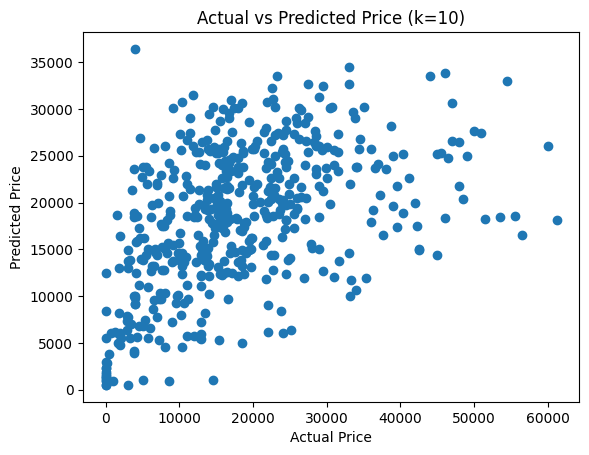

k=25, MSE: 103174289.15


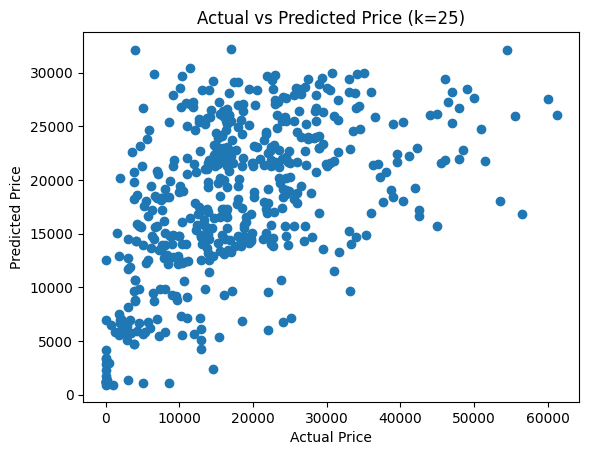

k=50, MSE: 99684175.91


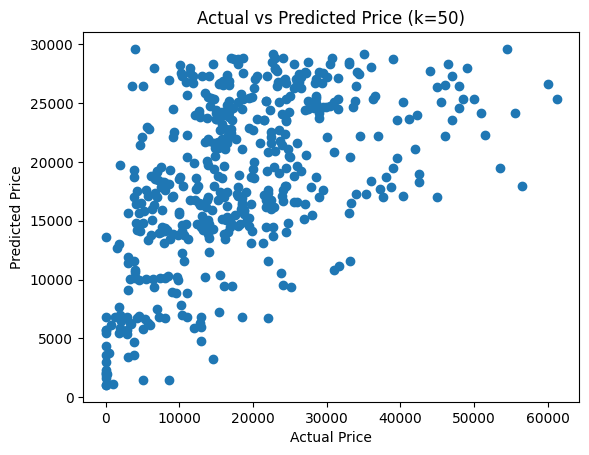

k=100, MSE: 98276515.02


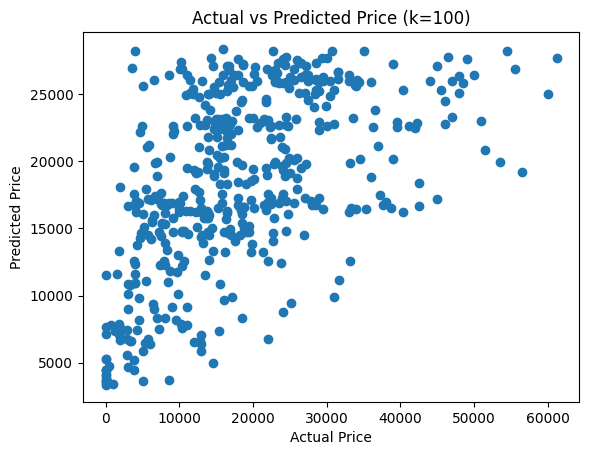

k=300, MSE: 100477298.91


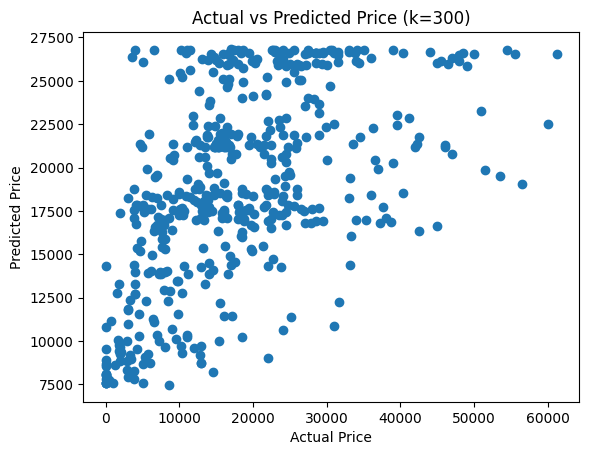

In [83]:
#4
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

def mse(y_test3,y_hat3):
    mse = np.sum( (y_test3 - y_hat3) ** 2 )/len(y_test3)
    return mse

mses = []
k_3 = [3, 10, 25, 50, 100, 300]
for k in k_3:
    model_3 = KNeighborsRegressor(n_neighbors = k) 
    model_3 = model_3.fit(u_train3,y_train3) 
    y_hat3 = model_3.predict(u_test3)
    error = mse(y_test3, y_hat3)
    mses.append(error)
    print(f"k={k}, MSE: {error:.2f}")
    plt.scatter(y_test3, y_hat3)
    plt.title(f"Actual vs Predicted Price (k={k})")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.show()

Question 4: As the k-value increases, the corresponding scatterplot shows less and less variance. k values of 3, 10, and 25 followed a scattered formation of a diagonal line. On the other hand, k values of 50, 100, and 300 created a horizontal line formation.

In [84]:
#5
index_star = np.argmin(mses)
k_star = k_3[index_star]
print(k_star)

100


Question 5: The optimal value of k is 100.

Question 6: The model overfits at lower values of k such as k = 3. The scatterplot points were spread out and followed in a diagonal line pattern. Since the model only looks at 3 neighbors, the model is much more sensitive to any outliers in data, creating a broader range of predicted values. On the flipside, the model underfits at higher values of k such as k = 300. The scatterplot points began forming a flat horizontal line. Since the model averages 300 neighbors, it ignores any unusual pieces of data and created a model that isn't totally accurate in showing the relationships between year, mileage, and price.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [85]:
#1
import numpy as np
import pandas as pd

df_4 = pd.read_csv('./data/airbnb_hw.csv', encoding='latin1')
df_4.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [86]:
#1
df_subset = df_4.loc[:, ['Review Scores Rating', 'Price', 'Beds']]
df_subset.head()

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0


In [87]:
#2
missing_reviews = df_subset.loc[df_subset['Review Scores Rating'].isnull(), :]
missing_reviews.head()

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
13,NaN,68,1.0


In [88]:
#3
cleaned_reviews = df_subset.dropna(axis=0, how='any').copy()
cleaned_reviews.head()

,Review Scores Rating,Price,Beds
4,96.0,549,3.0
5,100.0,149,1.0
6,100.0,250,1.0
7,94.0,90,1.0
8,90.0,270,2.0


In [89]:
#4
# I split the data into training and testing by 50/50.
from sklearn.model_selection import train_test_split

cleaned_reviews['Price'] = cleaned_reviews['Price'].astype(str).str.replace(',', '').astype(float)
# Need to first convert price to numbers from a string.

u_4 = cleaned_reviews[['Price', 'Beds']] 
y_4 = cleaned_reviews['Review Scores Rating']

scaler = MinMaxScaler()
u_4_scaled = scaler.fit_transform(u_4)

u_train4, u_test4, y_train4, y_test4 = train_test_split(u_4,y_4,
                                                    test_size=.2,
                                                    random_state=100) 

125


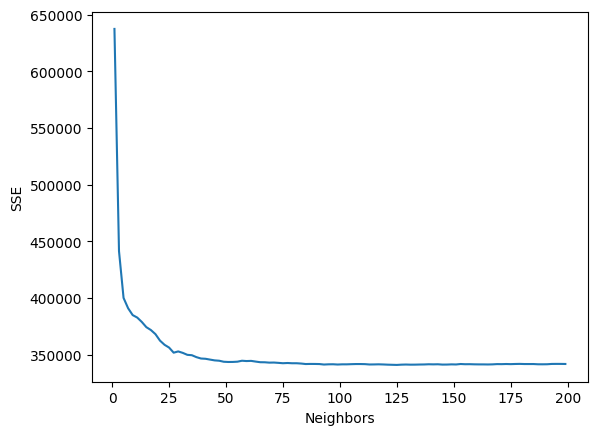

In [90]:
#4
from sklearn.neighbors import KNeighborsRegressor
import seaborn as sns

def sse(y_test4,y_hat4):
    sse = np.sum( (y_test4 - y_hat4) ** 2 )
    return sse

k_grid = [ (2*k+1) for k in range(100) ]
sses = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors = k)
    model = model.fit(u_train4,y_train4)
    y_hat4 = model.predict(u_test4) 
    sses.append( sse(y_test4, y_hat4) )
     
sns.lineplot(x=k_grid, y=sses).set(ylabel='SSE', xlabel='Neighbors')

index_star = np.argmin( sses ) 
k_star = k_grid[index_star]

print(k_star)

<Axes: xlabel='Review Scores Rating'>

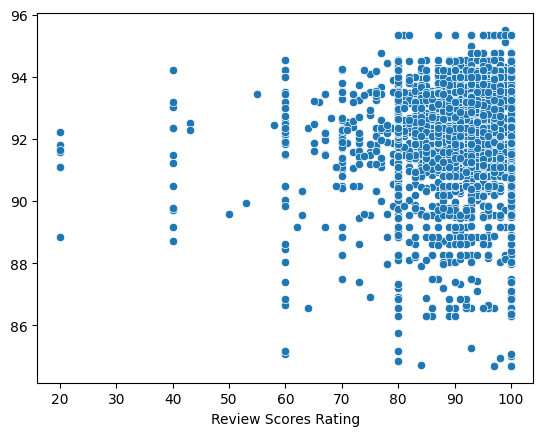

In [91]:
#4
k = 125 
model = KNeighborsRegressor(n_neighbors = k)
model = model.fit(u_train4,y_train4)
y_hat4 = model.predict(u_test4)

sns.scatterplot(x=y_test4, y=y_hat4)

Question 5: I predict that missing ratings are high between 80 and 100. I saw the sheer amount of data illustrated for ratings between 80 and 100 on the upper half of the y-axis; however, there was little to no data for the lower half of the y-axis.

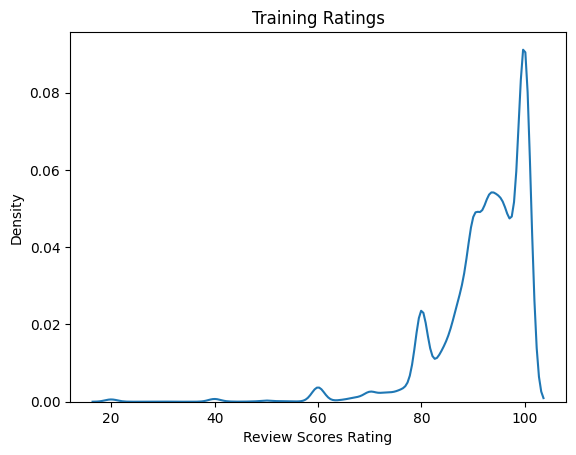

In [92]:
#6
import matplotlib.pyplot as plt
sns.kdeplot(cleaned_reviews['Review Scores Rating'])

plt.title("Training Ratings")
plt.show()


In [94]:
#6
missing_reviews.loc[:, 'Price'] = missing_reviews['Price'].astype(str).str.replace(',', '').astype(float)
# Need to first convert price to numbers from a string.
missing_reviews_clean = missing_reviews.dropna(subset=['Price', 'Beds'])
#Dropping rows that have NaN.

k = 125 
model = KNeighborsRegressor(n_neighbors = k)
model = model.fit(u_train4,y_train4)
missing_predicted = model.predict(missing_reviews_clean[['Price', 'Beds']])

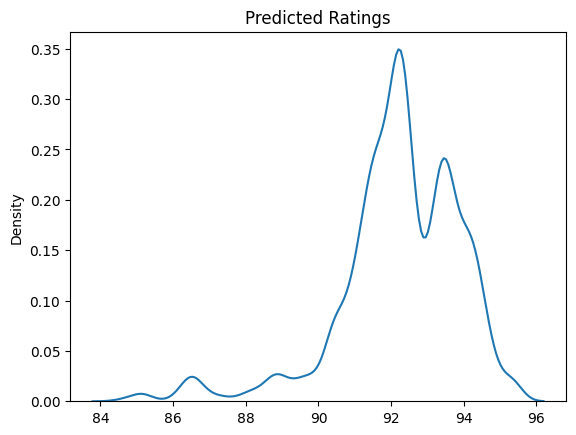

In [95]:
#6
sns.kdeplot(missing_predicted)

plt.title("Predicted Ratings")
plt.show()

Question 6: My plots do not look similar. The first immediate difference were the axes ranges used on each plot. The KDE plot for the training ratings included outlier values such as 20 and 40, which affected the x-axis. On the other hand, the predicted ratings KDE plot had a smaller x-axis range as it did not predict for any extreme values present in the training data.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)